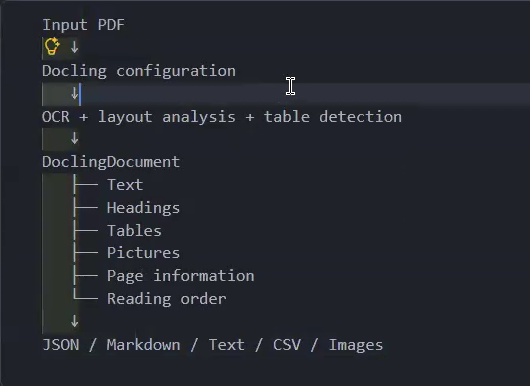

In [2]:
import json
from pathlib import Path
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    TableStructureOptions,
    TesseractCliOcrOptions,
)

from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)

from docling_core.types.doc import (
    ImageRefMode,
    PictureItem,
    TableItem,
)

print("All imports are successful")

All imports are successful


In [3]:
from pathlib import Path
# PDF file ka path store kar rahe hain
pdf_path = Path(
    r"D:\GEN AI BASICS\RAG\DATA-PARSING\Data\complex_rag_parsing_sample_with_sunny_image.pdf"
)
# Main output folder jahan saara processed data save hoga
output_dir = Path(
    r"D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output"
)
# PDF ke har page ki image save karne ka folder
page_image_dir = output_dir / "page_images"
# PDF se extract hui images save karne ka folder
picture_dir = output_dir / "extracted_pictures"
# PDF se extract hui tables save karne ka folder
table_dir = output_dir / "extracted_tables"
output_dir.mkdir(parents=True, exist_ok=True)
page_image_dir.mkdir(parents=True, exist_ok=True)
picture_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
if not pdf_path.exists():
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")
print("Folders created successfully and PDF found!")

Folders created successfully and PDF found!


In [4]:
#creating pipeline options for PDF processing
pipeline_options = PdfPipelineOptions()
#enable ocr
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions(
    tesseract_cmd=r"C:\Program Files\Tesseract-OCR\tesseract.exe",
    lang=["eng"],
)
#false= selectable text+ocr where required
#true= ocr complete pages
force_full_page_ocr = False
#enable table structure extractions
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options = TableStructureOptions(do_cell_matching=True)
#preserve page and picture images
pipeline_options.images_scale=2.0
pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True
print("Pipeline options created successfully")

Pipeline options created successfully


In [5]:
converter=DocumentConverter(
    format_options={
        InputFormat.PDF:PdfFormatOption(
            pipeline_options=pipeline_options,
        )
    }
)
print("DocumentConverter initialized successfully")

DocumentConverter initialized successfully


In [6]:
print("Parsing PDF with Docling...")
conversion_result = converter.convert(pdf_path)
print("docling conversion completed successfully.")
docling_document = conversion_result.document
print("PDF parsed successfully.")
print("Total pages:", len(docling_document.pages))
print("Total tables:", len(docling_document.tables))
print("Total pictures:", len(docling_document.pictures))

Parsing PDF with Docling...


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
Stage preprocess failed for run 1, pages [15]: std::bad_alloc
Stage preprocess failed for run 1, pages [16]: std::bad_alloc
Stage preprocess failed for run 1, pages [17]: std::bad_alloc
Stage preprocess failed for run 1, pages [18]: std::bad_alloc
Stage preprocess failed for run 1, pages [19]: std::bad_alloc
Stage preprocess failed for run 1, pages [20]: std::bad_alloc
Stage preprocess failed for run 1, pages [21]: std::bad_alloc
Stage preprocess failed for run 1, pages [22]: std::bad_alloc
Stage preprocess failed for run 1, pages [23]: std::bad_alloc
Stage preprocess failed for run 1, pages [24]: std::bad_alloc


docling conversion completed successfully.
PDF parsed successfully.
Total pages: 24
Total tables: 14
Total pictures: 4


In [7]:
json_output_path=output_dir / "docling_output.json"
json_output_path.write_text(
    json.dumps(
        docling_document.export_to_dict(),
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)
print(f"json output saved to {json_output_path}")


json output saved to D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\docling_output.json


In [8]:
markdown_output_path=output_dir / "docling_output.md"
docling_document.save_as_markdown(
    markdown_output_path,
    image_mode=ImageRefMode.REFERENCED,
)
print(f"markdown output saved to {markdown_output_path}")

markdown output saved to D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\docling_output.md


In [9]:
text_output_path = output_dir / "extracted_text.txt"

text_output_path.write_text(
    docling_document.export_to_markdown(strict_text=True),
    encoding="utf-8",
)

print("Plain text saved:", text_output_path)

Parameter `strict_text` has been deprecated and will be ignored.


Plain text saved: D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\extracted_text.txt


In [11]:
for page_number, page in docling_document.pages.items():
    if page.image is None:
        continue

    page_image_path = (
        page_image_dir / f"page_{page_number:03d}.png"
    )

    page.image.pil_image.save(page_image_path)

print("Page images saved:", page_image_dir)
   

Page images saved: D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\page_images


In [13]:
for table_index, table in enumerate(
    docling_document.tables,
    start=1,
):
    table_df = table.export_to_dataframe(
        doc=docling_document
    )

    csv_path = table_dir / f"table_{table_index:03d}.csv"
    markdown_path = table_dir / f"table_{table_index:03d}.md"
    image_path = table_dir / f"table_{table_index:03d}.png"

    table_df.to_csv(
        csv_path,
        index=False,
        encoding="utf-8",
    )

    markdown_path.write_text(
        table_df.to_markdown(index=False),
        encoding="utf-8",
    )

    table_image = table.get_image(docling_document)

    if table_image is not None:
        table_image.save(
            image_path,
            format="PNG",
        )

print("Tables saved:", table_dir)

Tables saved: D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\extracted_tables


In [14]:
picture_counter = 0

for element, _level in docling_document.iterate_items():

    if not isinstance(element, PictureItem):
        continue

    picture_counter += 1

    picture_path = (
        picture_dir
        / f"picture_{picture_counter:03d}.png"
    )

    picture_image = element.get_image(docling_document)

    if picture_image is not None:
        picture_image.save(
            picture_path,
            format="PNG",
        )

print("Pictures saved:", picture_dir)

Pictures saved: D:\GEN AI BASICS\RAG\DATA-PARSING\Data\docling-output\extracted_pictures
